D:\Projects\tumor-immune-scrna-atlas
categories: 0, 1, 2, etc.
var_group_labels: Epithelial, T_CD3, T_CD8, etc.


C:\Users\akksh\AppData\Local\Temp\ipykernel_322912\756136261.py:27: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.dotplot(


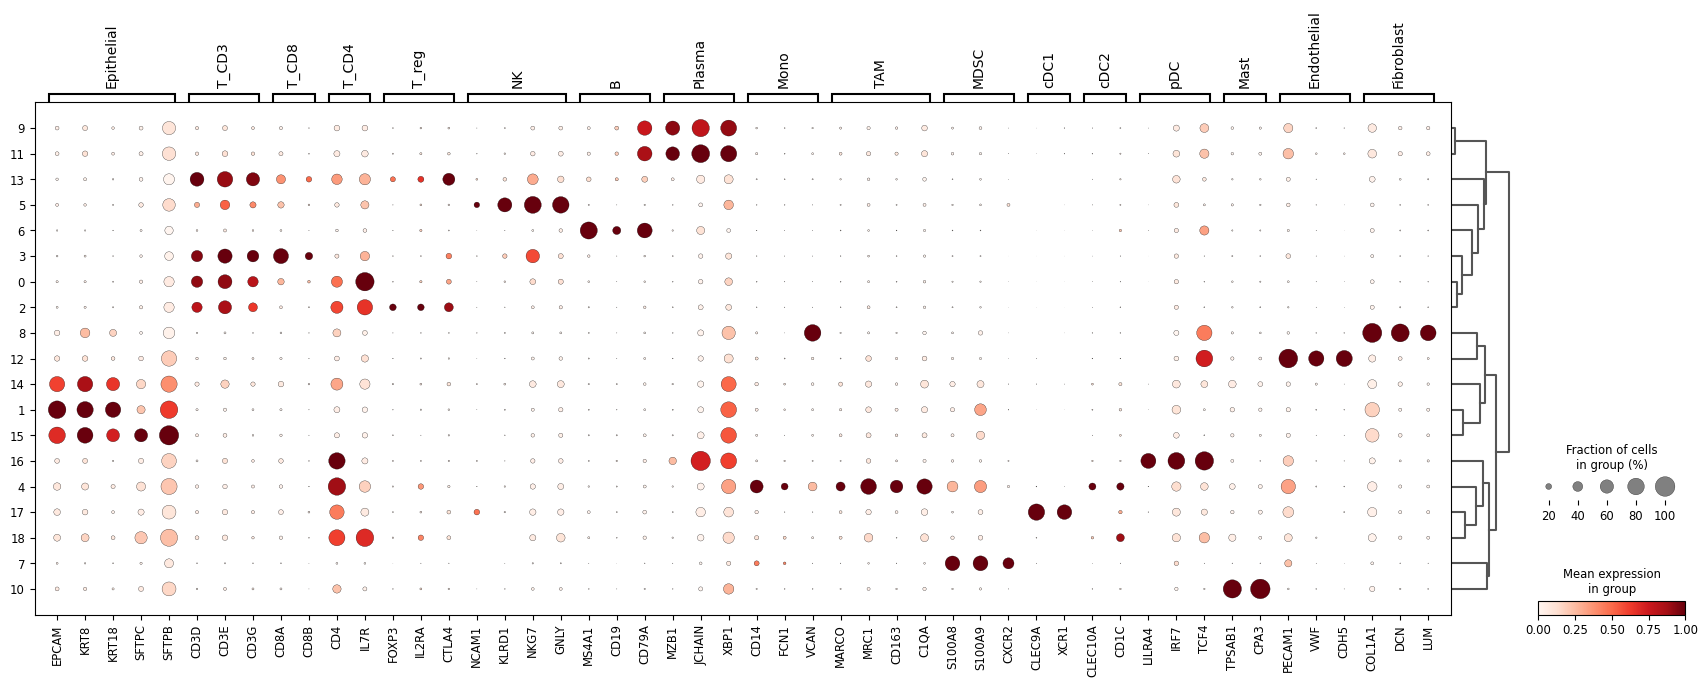

In [5]:
import os
os.chdir('D:/Projects/tumor-immune-scrna-atlas')
print(os.getcwd())

import scanpy as sc
adata = sc.read_h5ad('data/interim/07_celltypist.h5ad')
 
markers = {
    'Epithelial':  ['EPCAM', 'KRT8', 'KRT18', 'SFTPC', 'SFTPB'],
    'T_CD3':       ['CD3D', 'CD3E', 'CD3G'],
    'T_CD8':       ['CD8A', 'CD8B'],
    'T_CD4':       ['CD4', 'IL7R'],
    'T_reg':       ['FOXP3', 'IL2RA', 'CTLA4'],
    'NK':          ['NCAM1', 'KLRD1', 'NKG7', 'GNLY'],
    'B':           ['MS4A1', 'CD19', 'CD79A'],
    'Plasma':      ['MZB1', 'JCHAIN', 'XBP1'],
    'Mono':        ['CD14', 'FCN1', 'VCAN'],
    'TAM':         ['MARCO', 'MRC1', 'CD163', 'C1QA'],
    'MDSC':        ['S100A8', 'S100A9', 'CXCR2'],   # key for paper
    'cDC1':        ['CLEC9A', 'XCR1'],
    'cDC2':        ['CLEC10A', 'CD1C'],
    'pDC':         ['LILRA4', 'IRF7', 'TCF4'],
    'Mast':        ['TPSAB1', 'CPA3'],
    'Endothelial': ['PECAM1', 'VWF', 'CDH5'],
    'Fibroblast':  ['COL1A1', 'DCN', 'LUM'],
}
sc.pl.dotplot(
    adata, markers, groupby='leiden',
    dendrogram=True, save='_markers_dotplot.png',
    standard_scale='var',
)

In [8]:
cluster_to_type = {
    '0':  'T_CD4',
    '1':  'Malignant_epi',
    '2':  'T_CD8',
    '3':  'T_CD8',
    '4':  'TAM',
    '5':  'NK',
    '6':  'B',
    '7':  'Monocyte',
    '8':  'Fibroblast',
    '9':  'Plasma',
    '10': 'pDC',
    '11': 'Plasma',
    '12': 'Endothelial',
    '13': 'T_CD4',
    '14': 'Malignant_epi',
    '15': 'Malignant_epi',
    '16': 'Mast',
    '17': 'MDSC',          # key for the paper's biology
    '18': 'Treg',
}

adata.obs['cell_type'] = adata.obs['leiden'].astype(str).map(
    cluster_to_type).astype('category')

# Sanity check no NaN labels
missing = adata.obs['cell_type'].isna().sum()
assert missing == 0, f'{missing} cells have no cell_type'

In [9]:
all_clusters = set(adata.obs['leiden'].astype(str).unique())
mapped_clusters = set(cluster_to_type.keys())
unmapped = sorted(all_clusters - mapped_clusters, key=lambda x: int(x))
print(f"Unmapped clusters: {unmapped}")
print(f"Cell counts:\n{adata.obs[adata.obs['leiden'].astype(str).isin(unmapped)]['leiden'].value_counts()}")

Unmapped clusters: []
Cell counts:
leiden
0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
Name: count, dtype: int64


# The centerpiece UMAP

C:\Users\akksh\AppData\Local\Temp\ipykernel_322912\1290639541.py:1: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi_save=300)
C:\Users\akksh\AppData\Local\Temp\ipykernel_322912\1290639541.py:4: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


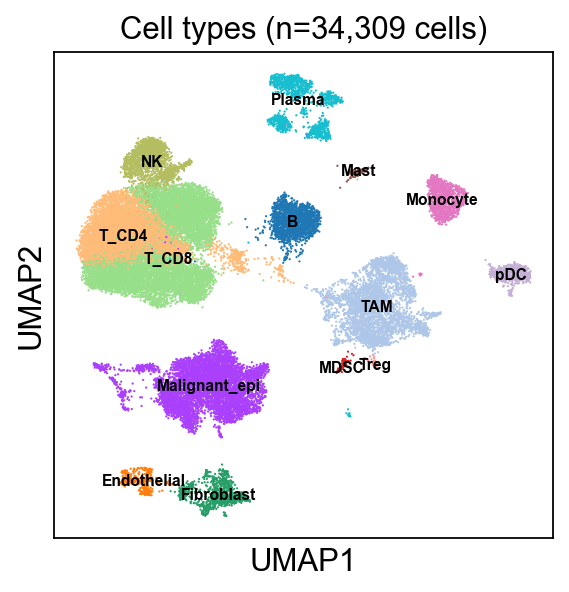

C:\Users\akksh\AppData\Local\Temp\ipykernel_322912\1290639541.py:11: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


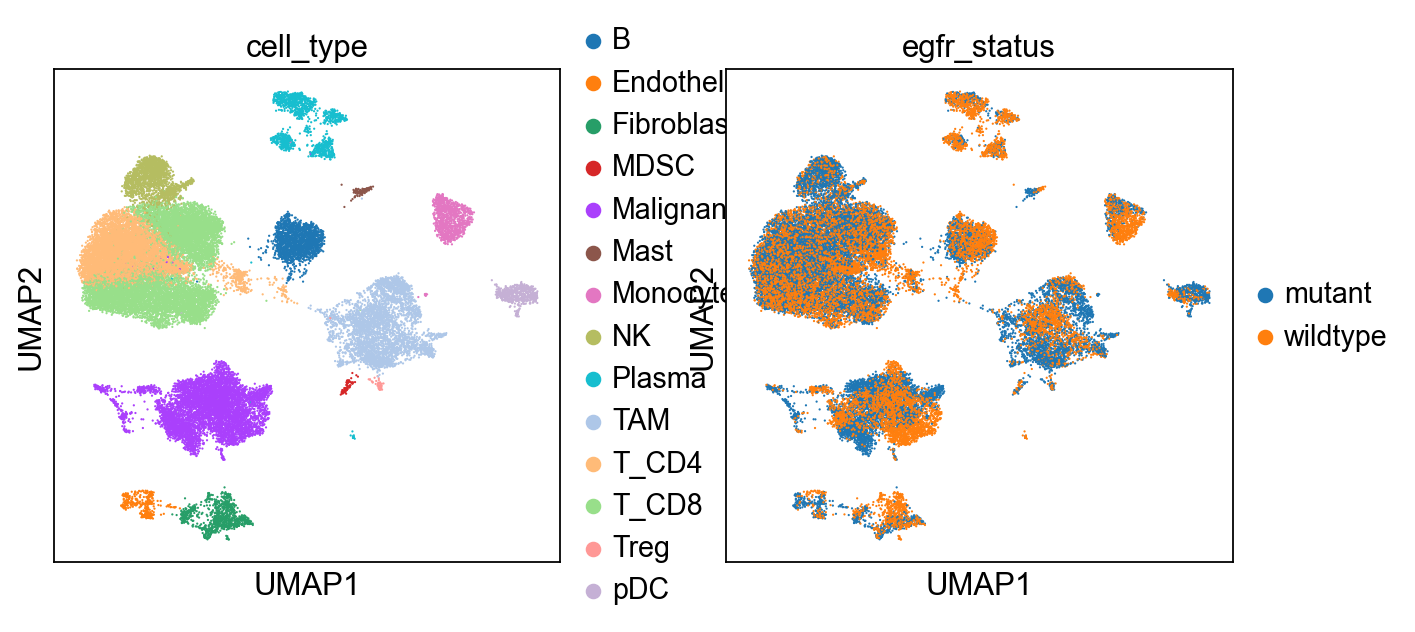

In [10]:
sc.settings.set_figure_params(dpi_save=300)
 
# Main annotated figure
sc.pl.umap(
    adata, color='cell_type', legend_loc='on data',
    legend_fontsize=7, title='Cell types (n={:,} cells)'.format(adata.n_obs),
    save='_annotated.png', size=4,
)
 
# Side-by-side: cell type vs EGFR status — the biology preview
sc.pl.umap(
    adata, color=['cell_type', 'egfr_status'],
    ncols=2, save='_celltype_vs_egfr.png', size=4,
)
 
# Save final annotated object
import os
os.makedirs('data/processed', exist_ok=True)
adata.write('data/processed/annotated.h5ad')
 
# Disk cleanup
for f in ['04_normalized', '05_integrated', '06_clustered', '07_celltypist']:
    p = f'data/interim/{f}.h5ad'
    if os.path.exists(p):
        os.remove(p)